**Question 1: What is Boosting in Machine Learning? Explain how it improves weak learners.**

**Answer:**  
Boosting is an ensemble technique that combines multiple weak learners (models that perform slightly better than random guessing) to create a strong learner. It works by training models sequentially, where each new model focuses on correcting the errors made by the previous ones. By iteratively adjusting weights on misclassified samples, boosting reduces bias and variance, leading to improved accuracy and robustness.

**Question 2: What is the difference between AdaBoost and Gradient Boosting in terms of how models are trained?**

**Answer:**

- **AdaBoost:** Assigns weights to training samples. Misclassified samples get higher weights so subsequent learners focus more on them. It combines learners using weighted majority voting.

- **Gradient Boosting:** Optimizes a loss function directly by fitting new learners to the residual errors of previous models. It uses gradient descent to minimize errors, making it more flexible and powerful than AdaBoost.

**Question 3: How does regularization help in XGBoost?**

**Answer:**  
Regularization in XGBoost (via parameters like lambda and alpha) penalizes overly complex models. It prevents overfitting by controlling the weights of features and limiting tree depth. This ensures better generalization on unseen data and stabilizes training.

**Question 4: Why is CatBoost considered efficient for handling categorical data?**

**Answer:**  
CatBoost uses ordered target statistics and efficient encoding techniques to transform categorical features without extensive preprocessing. Unlike one-hot encoding, CatBoost handles categorical variables natively, reducing dimensionality and avoiding overfitting.

**Question 5: What are some real-world applications where boosting techniques are preferred over bagging methods?**

**Answer:**

- Fraud detection in banking

- Customer churn prediction

- Medical diagnosis (e.g., cancer detection)

- Credit scoring and loan default prediction

- Recommendation systems

Boosting is preferred when accuracy and handling complex relationships are critical.

**Question 6: Python Program - AdaBoost Classifier on Breast Cancer Dataset**

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = AdaBoostClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.9736842105263158


**Question 7: Python Program - Gradient Boosting Regressor on California Housing Dataset**

In [2]:
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X, y = fetch_california_housing(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("R-squared:", r2_score(y_test, y_pred))


R-squared: 0.8004451261281281


**Question 8: Python Program - XGBoost Classifier with GridSearchCV**

In [3]:
from sklearn.datasets import load_breast_cancer
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

param_grid = {'learning_rate': [0.01, 0.05, 0.1, 0.2]}
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
grid = GridSearchCV(model, param_grid, cv=3, scoring='accuracy')
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("Best Params:", grid.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:47:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:47:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:47:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:47:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

Best Params: {'learning_rate': 0.1}
Accuracy: 0.956140350877193


**Question 9: Python Program – CatBoost Classifier with Confusion Matrix.**

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.8 MB/s eta 0:00:00


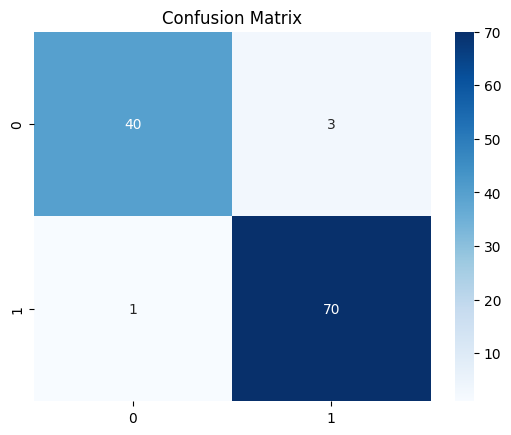

In [5]:
import sys
if 'google.colab' in sys.modules:
  !pip install catboost
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = CatBoostClassifier(iterations=200, verbose=0)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

**Question 10: FinTech Loan Default Prediction Pipeline**

Answer:  
Step-by-step pipeline:

1. Data Preprocessing:

- Handle missing values using imputation (mean for numeric, mode for categorical).

- Encode categorical features (CatBoost handles them natively, otherwise use one-hot/target encoding).

- Normalize numeric features if needed.

2. Choice of Model:

- CatBoost is ideal due to mixed data types and categorical features.

- XGBoost can also be used with proper encoding.

3. Hyperparameter Tuning:

- Use GridSearchCV or RandomizedSearchCV for parameters like learning rate, depth, n_estimators.

- Employ early stopping to avoid overfitting.

4. Evaluation Metrics:

- Since the dataset is imbalanced, use AUC-ROC, Precision, Recall, F1-score instead of just accuracy.

- Confusion matrix to visualize performance.

5. Business Benefit:

- Helps identify high-risk customers early.

- Reduces financial losses by minimizing defaults.

- Improves customer trust and enables better loan approval strategies.

In [6]:
#Python Example (simplified):
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Assume preprocessed data: X, y
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = CatBoostClassifier(iterations=500, depth=8, learning_rate=0.1, verbose=0)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

